
                  SCIENTIFIC ANALYSIS: CLOSED-LOOP OPTIMIZATION RESULTS                   
[A] COST BREAKDOWN ANALYSIS
 - Total Objective Cost : 877,581,243.30 CNY
 - Fixed Construction Cost: 333,000,000.00 CNY
 - Forward Logistics Cost : 435,852,925.30 CNY
 - Reverse Logistics Cost : 108,442,444.31 CNY

正在生成出版级高分辨率网络图...
>>> 网络图已保存: 50cities_optimized_vis_nw_unified.png

>>> 开始计算不同规模的求解时间...
Size: 10  | Vars: 303    | Status: Optimal    | Time: 0.0808 sec
Size: 20  | Vars: 583    | Status: Optimal    | Time: 0.0723 sec
Size: 30  | Vars: 863    | Status: Optimal    | Time: 0.2170 sec
Size: 40  | Vars: 1143   | Status: Optimal    | Time: 0.2835 sec
Size: 50  | Vars: 1423   | Status: Optimal    | Time: 1.8973 sec

--- 论文用数据 ---
规模		变量数		时间 (s)
10		303		0.0808
20		583		0.0723
30		863		0.2170
40		1143		0.2835
50		1423		1.8973

>>> 复杂性分析图已保存: complexity_analysis.png


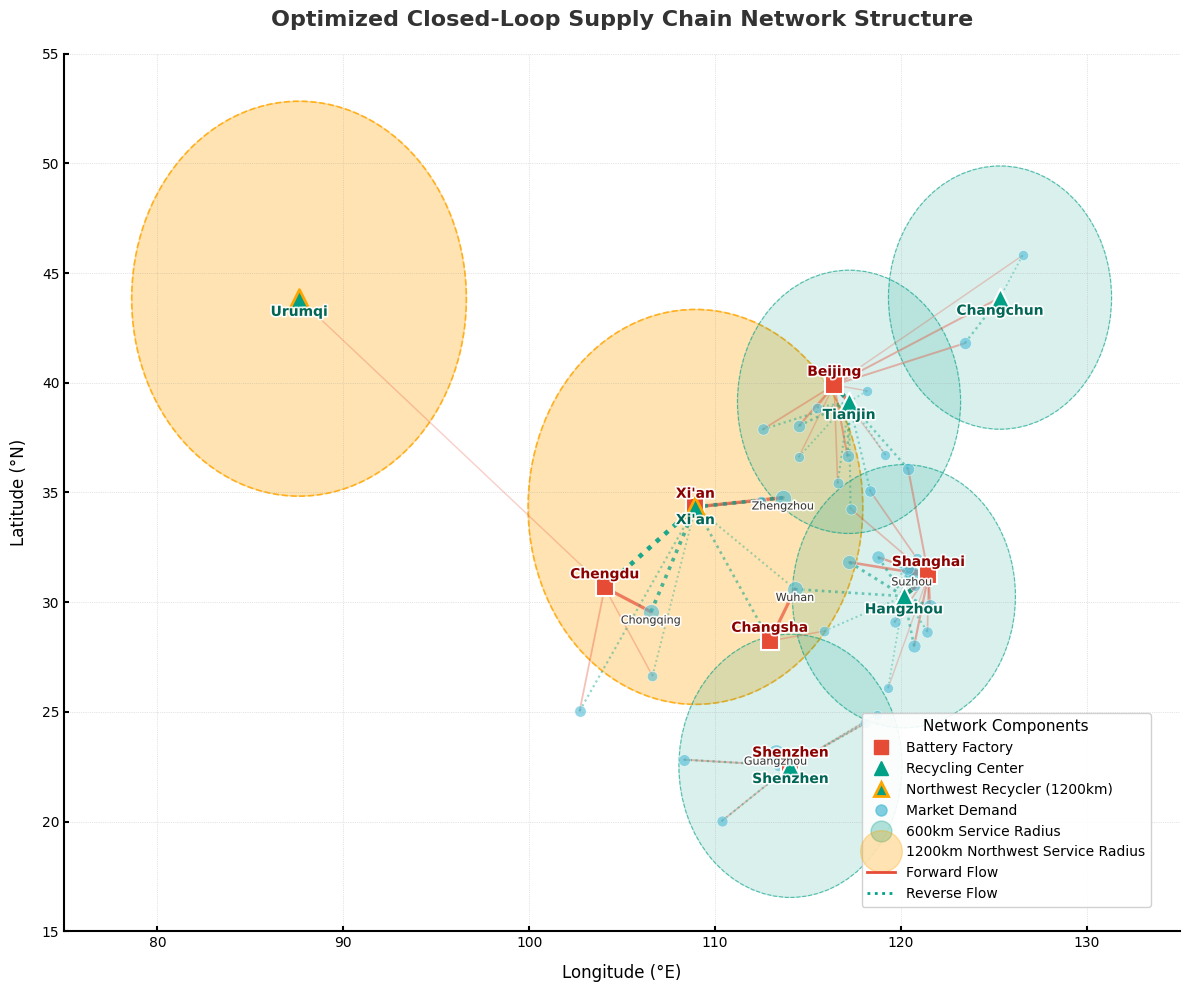

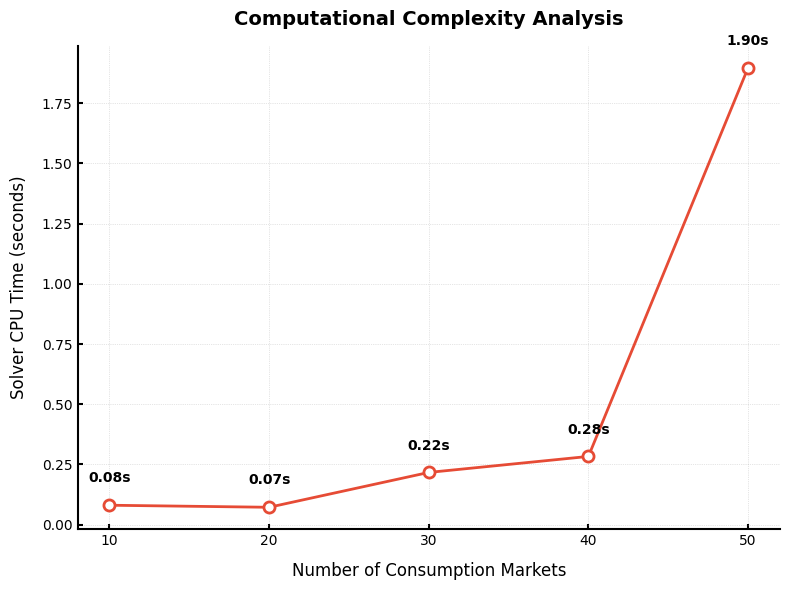

In [4]:
import pulp
import math
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.lines as mlines
import pandas as pd
import numpy as np
import time

# ==========================================
# 【核心配置与数据】
# ==========================================

# ---------------------- 1. 绘图样式固定参数 ----------------------
PLOT_CONFIG = {
 'font_family': 'sans-serif',
 'font_size': 10,
 'axes_titlesize': 14,
 'axes_labelsize': 12,
 'xtick_labelsize': 10,
 'ytick_labelsize': 10,
 'legend_fontsize': 10,
 'figure_dpi': 150,
 'savefig_dpi': 600,
 'style_colors': {
 'factory_fill': '#E64B35',
 'factory_edge': '#3C5488',
 'recycler_fill': '#00A087',
 'recycler_halo': '#00A087',
 'nw_recycler_halo': '#FFA500',
 'market_fill': '#4DBBD5',
 'fwd_line': '#E64B35',
 'rev_line': '#00A087',
 'text': '#333333'
 }
}

# ---------------------- 2. 区域约束参数 ----------------------
REGION_CONFIG = {
 'nw_cities': ["Urumqi", "Xi'an"],
 'max_rev_dist': 600,
 'max_rev_dist_nw': 1200,
 'nw_radius_visual': 9.0,
 'normal_radius_visual': 6.0,
 'earth_radius': 6371
}

# ---------------------- 3. 核心经济/政策参数 ----------------------
PAPER_PARAMS = {
 'trans_cost': 1.6,
 'carbon_tax': 65,
 'carbon_factor_fwd': 0.00005,
 'carbon_factor_rev': 0.00010,
 'carbon_cap': 16000,
 'single_recycler_capacity': 80000,
 'demand_uncertainty_rate': 0.2,
 'gamma': 1.0,
 'alpha': 0.28,
 'cost_unit_convert': 10000
}

# ---------------------- 4. 节点基础数据参数 ----------------------
CITY_DEMAND = {
 "Chengdu": 39500, "Hangzhou": 39200, "Shenzhen": 38400, "Shanghai": 37900,
 "Beijing": 37100, "Guangzhou": 35300, "Zhengzhou": 30300, "Chongqing": 28900,
 "Xi'an": 28800, "Tianjin": 28700, "Wuhan": 28100, "Suzhou": 28000,
 "Hefei": 21200, "Wuxi": 19500, "Ningbo": 19500, "Dongguan": 18400,
 "Nanjing": 18300, "Changsha": 17600, "Wenzhou": 17300, "Shijiazhuang": 15700,
 "Jinan": 15500, "Foshan": 15300, "Qingdao": 15200, "Changchun": 14800,
 "Shenyang": 14400, "Nanning": 13400, "Taiyuan": 12500, "Kunming": 12300,
 "Linyi": 12100, "Taizhou": 11700, "Jinhua": 11500, "Xuzhou": 11200,
 "Haikou": 10900, "Jining": 10600, "Xiamen": 10300, "Baoding": 10200,
 "Nanchang": 9700, "Changzhou": 9600, "Guiyang": 9300, "Luoyang": 9200,
 "Tangshan": 8700, "Nantong": 8700, "Harbin": 8600, "Handan": 8500,
 "Weifang": 8500, "Urumqi": 8200, "Quanzhou": 8200, "Fuzhou": 8100,
 "Zhongshan": 7800, "Jiaxing": 7800
}

CITY_COORDS = {
 "Chengdu": (30.67, 104.06), "Hangzhou": (30.27, 120.15), "Shenzhen": (22.54, 114.05),
 "Shanghai": (31.23, 121.47), "Beijing": (39.90, 116.40), "Guangzhou": (23.13, 113.26),
 "Zhengzhou": (34.76, 113.65), "Chongqing": (29.56, 106.55), "Xi'an": (34.34, 108.94),
 "Tianjin": (39.13, 117.20), "Wuhan": (30.59, 114.30), "Suzhou": (31.30, 120.58),
 "Hefei": (31.82, 117.22), "Wuxi": (31.57, 120.30), "Ningbo": (29.82, 121.55),
 "Dongguan": (23.05, 113.75), "Nanjing": (32.05, 118.78), "Changsha": (28.23, 112.94),
 "Wenzhou": (28.00, 120.70), "Shijiazhuang": (38.04, 114.51), "Jinan": (36.65, 117.12),
 "Foshan": (23.02, 113.12), "Qingdao": (36.07, 120.38), "Changchun": (43.88, 125.32),
 "Shenyang": (41.80, 123.43), "Nanning": (22.82, 108.32), "Taiyuan": (37.87, 112.55),
 "Kunming": (25.04, 102.71), "Linyi": (35.05, 118.35), "Taizhou": (28.66, 121.42),
 "Jinhua": (29.08, 119.65), "Xuzhou": (34.26, 117.28), "Haikou": (20.02, 110.35),
 "Jining": (35.42, 116.59), "Xiamen": (24.48, 118.08), "Baoding": (38.87, 115.48),
 "Nanchang": (28.68, 115.86), "Changzhou": (31.78, 119.95), "Guiyang": (26.64, 106.63),
 "Luoyang": (34.62, 112.45), "Tangshan": (39.63, 118.18), "Nantong": (32.01, 120.86),
 "Harbin": (45.80, 126.53), "Handan": (36.61, 114.49), "Weifang": (36.71, 119.16),
 "Urumqi": (43.83, 87.62), "Quanzhou": (24.87, 118.68), "Fuzhou": (26.08, 119.30),
 "Zhongshan": (22.52, 113.39), "Jiaxing": (30.75, 120.75)
}

RECYCLER_CONFIG = [
 ("Hefei", (31.82, 117.22), 5800), ("Zhengzhou", (34.76, 113.65), 5300),
 ("Guiyang", (26.64, 106.63), 5000), ("Changsha", (28.23, 112.94), 6200),
 ("Wuhan", (30.59, 114.30), 5800), ("Yibin", (28.77, 104.63), 7000),
 ("Nanchang", (28.68, 115.86), 5500), ("Xi'an", (34.34, 108.94), 5600),
 ("Tianjin", (39.13, 117.20), 5700), ("Nanjing", (32.05, 118.78), 5900),
 ("Hangzhou", (30.27, 120.15), 6000), ("Changchun", (43.88, 125.32), 4800),
 ("Nanning", (22.82, 108.32), 5200), ("Shenzhen", (22.54, 114.05), 6500),
 ("Qingdao", (36.07, 120.38), 5400), ("Harbin", (45.80, 126.53), 4600),
 ("Fuzhou", (26.08, 119.30), 5100), ("Xiamen", (24.48, 118.08), 5300),
 ("Kunming", (25.04, 102.71), 4900), ("Urumqi", (43.83, 87.62), 4700),
 ("Haikou", (20.02, 110.35), 5000), ("Shenyang", (41.80, 123.43), 4900)
]

FACTORY_CONFIG = [
 ("Xi'an", (34.34, 108.94)), ("Changsha", (28.23, 112.94)),
 ("Shenzhen", (22.54, 114.05)), ("Shanghai", (31.23, 121.47)),
 ("Chengdu", (30.67, 104.06)), ("Beijing", (39.90, 116.40))
]

# ==========================================
# 【第一步至第四步：基础模型构建（完整版）】
# ==========================================

# ---------------------- 辅助函数 ----------------------
def is_nw_city(city_name):
    city = city_name.replace("M_", "").replace("R_", "").replace("F_", "")
    return city in REGION_CONFIG['nw_cities']

def haversine_dist(n1, n2, locations):
    lat1, lon1 = locations[n1]
    lat2, lon2 = locations[n2]
    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    a = math.sin(dlat / 2) ** 2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon / 2) ** 2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return REGION_CONFIG['earth_radius'] * c

def add_smart_label(pos, text, color, size=9, weight='bold', dy=0):
    txt = plt.text(pos[1], pos[0] + dy, text, fontsize=size, fontweight=weight, color=color,
                   ha='center', va='center', zorder=50)
    txt.set_path_effects([pe.withStroke(linewidth=2.5, foreground='white', alpha=0.9)])

# ---------------------- 数据构建 ----------------------
locations = {}
for c, pos in FACTORY_CONFIG: locations[f"F_{c}"] = pos
for c in CITY_DEMAND.keys(): locations[f"M_{c}"] = CITY_COORDS[c]
for c, pos, _ in RECYCLER_CONFIG: locations[f"R_{c}"] = pos

fixed_cost = {f"R_{c}": cost * PAPER_PARAMS['cost_unit_convert'] for c, _, cost in RECYCLER_CONFIG}
demand_base = {f"M_{c}": CITY_DEMAND[c] for c in CITY_DEMAND.keys()}
demand_uncertainty = {k: v * PAPER_PARAMS['demand_uncertainty_rate'] for k, v in demand_base.items()}

get_dist = lambda n1, n2: haversine_dist(n1, n2, locations)

# ---------------------- 50 城模型构建 ----------------------
prob = pulp.LpProblem("CLSC_Full_Model", pulp.LpMinimize)
factories = [f"F_{c}" for c, _ in FACTORY_CONFIG]
markets = [f"M_{c}" for c in CITY_DEMAND.keys()]
candidates = [f"R_{c}" for c, _, _ in RECYCLER_CONFIG]

x = pulp.LpVariable.dicts("Fwd", (factories, markets), 0)
z = pulp.LpVariable.dicts("Rev", (markets, candidates), 0)
y = pulp.LpVariable.dicts("Open", candidates, cat='Binary')
excess_e = pulp.LpVariable("ExcessE", 0)

# 目标函数
cost_fwd = pulp.lpSum([x[i][j] * get_dist(i, j) * PAPER_PARAMS['trans_cost'] for i in factories for j in markets])
cost_rev = pulp.lpSum([z[j][k] * get_dist(j, k) * PAPER_PARAMS['trans_cost'] for j in markets for k in candidates])
cost_fix = pulp.lpSum([fixed_cost[k] * y[k] for k in candidates])

prob += cost_fix + cost_fwd + cost_rev + excess_e * PAPER_PARAMS['carbon_tax']

# 碳约束
emit_fwd = pulp.lpSum([x[i][j] * get_dist(i, j) * PAPER_PARAMS['carbon_factor_fwd'] for i in factories for j in markets])
emit_rev = pulp.lpSum([z[j][k] * get_dist(j, k) * PAPER_PARAMS['carbon_factor_rev'] for j in markets for k in candidates])
prob += excess_e >= (emit_fwd + emit_rev) - PAPER_PARAMS['carbon_cap']

# 需求与回收约束 + 区域约束
for j in markets:
    prob += pulp.lpSum([x[i][j] for i in factories]) >= demand_base[j] + PAPER_PARAMS['gamma'] * demand_uncertainty[j]
    prob += pulp.lpSum([z[j][k] for k in candidates]) >= demand_base[j] * PAPER_PARAMS['alpha']

    for k in candidates:
        dist = get_dist(j, k)
        if is_nw_city(j) or is_nw_city(k):
            if dist > REGION_CONFIG['max_rev_dist_nw']:
                prob += z[j][k] == 0
        else:
            if dist > REGION_CONFIG['max_rev_dist']:
                prob += z[j][k] == 0

for k in candidates:
    prob += pulp.lpSum([z[j][k] for j in markets]) <= PAPER_PARAMS['single_recycler_capacity'] * y[k]

nw_recyclers = [k for k in candidates if is_nw_city(k)]
if nw_recyclers:
    prob += pulp.lpSum([y[k] for k in nw_recyclers]) >= 1

# ---------------------- 求解 ----------------------
prob.solve(pulp.PULP_CBC_CMD(msg=False))

# ==========================================
# 【第五步与第六步：结果输出与绘图（完整版）】
# ==========================================
if pulp.LpStatus[prob.status] == 'Optimal':
    tc = pulp.value(prob.objective)
    built_k = [k for k in candidates if pulp.value(y[k]) > 0.5]
    total_qty_fwd = sum(pulp.value(x[i][j]) for i in factories for j in markets)
    total_qty_rev = sum(pulp.value(z[j][k]) for j in markets for k in candidates)

    print("\n" + "=" * 90)
    print(f"{'SCIENTIFIC ANALYSIS: CLOSED-LOOP OPTIMIZATION RESULTS':^90}")
    print("=" * 90)
    print(f"[A] COST BREAKDOWN ANALYSIS")
    print(f" - Total Objective Cost : {tc:,.2f} CNY")
    print(f" - Fixed Construction Cost: {pulp.value(cost_fix):,.2f} CNY")
    print(f" - Forward Logistics Cost : {pulp.value(cost_fwd):,.2f} CNY")
    print(f" - Reverse Logistics Cost : {pulp.value(cost_rev):,.2f} CNY")
    print("=" * 90)

    print("\n正在生成出版级高分辨率网络图...")
    plt.rcParams.update({
     'font.family': PLOT_CONFIG['font_family'], 'font.size': PLOT_CONFIG['font_size'],
     'axes.linewidth': 1.5, 'xtick.major.width': 1.5, 'ytick.major.width': 1.5,
     'xtick.direction': 'in', 'ytick.direction': 'in'
    })

    fig, ax = plt.subplots(figsize=(12, 10))
    ax.set_aspect(1.18)
    STYLE_COLORS = PLOT_CONFIG['style_colors']
    max_flow_fwd = max([pulp.value(x[i][j]) for i in factories for j in markets] + [1])
    max_flow_rev = max([pulp.value(z[j][k]) for j in markets for k in candidates] + [1])
    max_demand = max(demand_base.values())
    built_cities = [k.replace('R_', '') for k in built_k]
    factory_cities = [f.replace('F_', '') for f in factories]

    # 正向物流
    for i in factories:
     for j in markets:
        val = pulp.value(x[i][j])
        if val > 100:
            p1, p2 = locations[i], locations[j]
            norm_val = val / max_flow_fwd
            ax.plot([p1[1], p2[1]], [p1[0], p2[0]],
             c=STYLE_COLORS['fwd_line'], alpha=0.1 + norm_val * 0.8, 
             linewidth=0.5 + norm_val * 2.5, zorder=2, solid_capstyle='round')

    # 逆向物流
    for j in markets:
     for k in built_k:
        val = pulp.value(z[j][k])
        if val > 10:
            p1, p2 = locations[j], locations[k]
            norm_val = val / max_flow_rev
            ax.plot([p1[1], p2[1]], [p1[0], p2[0]],
             c=STYLE_COLORS['rev_line'], alpha=0.2 + norm_val * 0.7, 
             linewidth=0.8 + norm_val * 2.5, linestyle=(0, (1, 1.5)), zorder=3)

    # 节点绘制
    for m in markets:
        city_name = m.replace('M_', '')
        pos = locations[m]
        size = 20 + (demand_base[m] / max_demand) * 150
        if city_name not in built_cities and city_name not in factory_cities:
            ax.scatter(pos[1], pos[0], s=size, c=STYLE_COLORS['market_fill'], alpha=0.6, edgecolors='white', lw=0.5, zorder=4)
            if demand_base[m] > sorted(demand_base.values(), reverse=True)[12]:
                add_smart_label(pos, city_name, STYLE_COLORS['text'], size=8, weight='normal', dy=-0.4)

    for k in built_k:
        pos = locations[k]
        city_name = k.replace('R_', '')
        radius = REGION_CONFIG['nw_radius_visual'] if is_nw_city(k) else REGION_CONFIG['normal_radius_visual']
        color = STYLE_COLORS['nw_recycler_halo'] if is_nw_city(k) else STYLE_COLORS['recycler_halo']
        ax.add_patch(plt.Circle((pos[1], pos[0]), radius, color=color, alpha=0.3 if is_nw_city(k) else 0.15, zorder=1))
        ax.add_patch(plt.Circle((pos[1], pos[0]), radius, fill=False, edgecolor=color, linestyle='--', linewidth=1.2 if is_nw_city(k) else 0.8, alpha=0.8 if is_nw_city(k) else 0.6, zorder=1))
        ax.scatter(pos[1], pos[0], c=STYLE_COLORS['recycler_fill'], marker='^', s=200, edgecolors=color if is_nw_city(k) else 'white', lw=2.0 if is_nw_city(k) else 1.5, zorder=20)
        add_smart_label(pos, city_name, '#006655', size=10, weight='bold', dy=-0.6)

    for f in factories:
        pos = locations[f]
        ax.scatter(pos[1], pos[0], c=STYLE_COLORS['factory_fill'], marker='s', s=180, edgecolors='white', lw=1.5, zorder=15)
        add_smart_label(pos, f.replace('F_', ''), '#8B0000', size=10, weight='bold', dy=0.6)

    legend_elements = [
     mlines.Line2D([], [], color=STYLE_COLORS['factory_fill'], marker='s', linestyle='None', markersize=10, label='Battery Factory'),
     mlines.Line2D([], [], color=STYLE_COLORS['recycler_fill'], marker='^', linestyle='None', markersize=10, label='Recycling Center'),
     mlines.Line2D([], [], color=STYLE_COLORS['recycler_fill'], marker='^', linestyle='None', markersize=10, markeredgecolor=STYLE_COLORS['nw_recycler_halo'], markeredgewidth=2, label='Northwest Recycler (1200km)'),
     mlines.Line2D([], [], color=STYLE_COLORS['market_fill'], marker='o', linestyle='None', markersize=8, alpha=0.7, label='Market Demand'),
     mlines.Line2D([], [], color=STYLE_COLORS['recycler_halo'], marker='o', linestyle='None', markersize=15, alpha=0.3, label='600km Service Radius'),
     mlines.Line2D([], [], color=STYLE_COLORS['nw_recycler_halo'], marker='o', linestyle='None', markersize=30, alpha=0.3, label='1200km Northwest Service Radius'),
     mlines.Line2D([], [], color=STYLE_COLORS['fwd_line'], lw=2, label='Forward Flow'),
     mlines.Line2D([], [], color=STYLE_COLORS['rev_line'], lw=2, linestyle=':', label='Reverse Flow'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10, frameon=True, fancybox=True, framealpha=0.9, edgecolor='#CCCCCC', bbox_to_anchor=(0.98, 0.02), title="Network Components", title_fontsize=11)
    ax.set_title("Optimized Closed-Loop Supply Chain Network Structure", fontsize=16, fontweight='bold', pad=20, color='#333333')
    ax.set_xlabel("Longitude (°E)", fontsize=12, labelpad=10)
    ax.set_ylabel("Latitude (°N)", fontsize=12, labelpad=10)
    ax.set_xlim(75, 135)
    ax.set_ylim(15, 55)
    ax.grid(True, linestyle=':', linewidth=0.5, color='#999999', alpha=0.5, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig("50cities_optimized_vis_nw_unified.png", bbox_inches='tight', dpi=PLOT_CONFIG['savefig_dpi'])
    print(">>> 网络图已保存: 50cities_optimized_vis_nw_unified.png")
    # 不要在这里 show，让脚本继续跑复杂性分析

# ==========================================
# 【第七步：计算复杂性分析（响应审稿人）】
# ==========================================
print("\n>>> 开始计算不同规模的求解时间...")

# 准备不同规模的市场列表（取前 N 个需求最大的城市）
all_market_cities = list(CITY_DEMAND.keys())
sizes_to_test = [10, 20, 30, 40, 50]
time_costs = []
var_counts = []

for size in sizes_to_test:
    # 截取前 size 个城市
    subset_cities = all_market_cities[:size]
    
    # 构建子集数据
    sub_demand_base = {f"M_{c}": CITY_DEMAND[c] for c in subset_cities}
    sub_demand_uncertainty = {k: v * PAPER_PARAMS['demand_uncertainty_rate'] for k, v in sub_demand_base.items()}
    sub_markets = [f"M_{c}" for c in subset_cities]
    
    # 复用工厂和回收中心列表
    sub_factories = [f"F_{c}" for c, _ in FACTORY_CONFIG]
    sub_candidates = [f"R_{c}" for c, _, _ in RECYCLER_CONFIG]
    
    # 建立新模型（使用不同变量名避免污染）
    sub_prob = pulp.LpProblem(f"CLSC_Size_{size}", pulp.LpMinimize)
    x_sub = pulp.LpVariable.dicts("x", (sub_factories, sub_markets), 0)
    z_sub = pulp.LpVariable.dicts("z", (sub_markets, sub_candidates), 0)
    y_sub = pulp.LpVariable.dicts("y", sub_candidates, cat='Binary')
    e_excess_sub = pulp.LpVariable("e_excess", 0)
    
    num_vars = len(x_sub) * len(x_sub[sub_factories[0]]) + len(z_sub) * len(z_sub[sub_markets[0]]) + len(y_sub) + 1
    var_counts.append(num_vars)
    
    # 目标函数与约束构建
    sub_cost_fix = pulp.lpSum([fixed_cost[k] * y_sub[k] for k in sub_candidates])
    sub_cost_fwd = pulp.lpSum([x_sub[i][j] * haversine_dist(i, j, locations) * PAPER_PARAMS['trans_cost'] for i in sub_factories for j in sub_markets])
    sub_cost_rev = pulp.lpSum([z_sub[j][k] * haversine_dist(j, k, locations) * PAPER_PARAMS['trans_cost'] for j in sub_markets for k in sub_candidates])
    
    sub_prob += sub_cost_fix + sub_cost_fwd + sub_cost_rev + e_excess_sub * PAPER_PARAMS['carbon_tax']
    sub_prob += e_excess_sub >= (
        pulp.lpSum([x_sub[i][j] * haversine_dist(i, j, locations) * PAPER_PARAMS['carbon_factor_fwd'] for i in sub_factories for j in sub_markets]) +
        pulp.lpSum([z_sub[j][k] * haversine_dist(j, k, locations) * PAPER_PARAMS['carbon_factor_rev'] for j in sub_markets for k in sub_candidates])
    ) - PAPER_PARAMS['carbon_cap']
    
    for j in sub_markets:
        sub_prob += pulp.lpSum([x_sub[i][j] for i in sub_factories]) >= sub_demand_base[j] + PAPER_PARAMS['gamma'] * sub_demand_uncertainty[j]
        sub_prob += pulp.lpSum([z_sub[j][k] for k in sub_candidates]) >= sub_demand_base[j] * PAPER_PARAMS['alpha']
        
        for k in sub_candidates:
            dist = haversine_dist(j, k, locations)
            city_name_j = j.replace("M_", "")
            city_name_k = k.replace("R_", "")
            is_nw = city_name_j in REGION_CONFIG['nw_cities'] or city_name_k in REGION_CONFIG['nw_cities']
            limit = REGION_CONFIG['max_rev_dist_nw'] if is_nw else REGION_CONFIG['max_rev_dist']
            if dist > limit:
                sub_prob += z_sub[j][k] == 0
                
    for k in sub_candidates:
        sub_prob += pulp.lpSum([z_sub[j][k] for j in sub_markets]) <= PAPER_PARAMS['single_recycler_capacity'] * y_sub[k]
        
    nw_recyclers_sub = [k for k in sub_candidates if is_nw_city(k)]
    if nw_recyclers_sub:
        sub_prob += pulp.lpSum([y_sub[k] for k in nw_recyclers_sub]) >= 1

    # 计时求解
    start = time.time()
    sub_prob.solve(pulp.PULP_CBC_CMD(msg=False, timeLimit=60))
    end = time.time()
    
    elapsed = end - start
    time_costs.append(elapsed)
    
    status = pulp.LpStatus[sub_prob.status]
    print(f"Size: {size:<3} | Vars: {num_vars:<6} | Status: {status:<10} | Time: {elapsed:.4f} sec")

# 输出表格数据（方便你写论文）
print("\n--- 论文用数据 ---")
print("规模\t\t变量数\t\t时间 (s)")
for s, v, t in zip(sizes_to_test, var_counts, time_costs):
    print(f"{s}\t\t{v}\t\t{t:.4f}")

# 绘图部分（严格遵循 PLOT_CONFIG）
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(sizes_to_test, time_costs, marker='o', linestyle='-', 
        color=PLOT_CONFIG['style_colors']['fwd_line'], linewidth=2, 
        markersize=8, markerfacecolor='white', markeredgewidth=2)

ax.set_title('Computational Complexity Analysis', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Consumption Markets', fontsize=12, labelpad=10)
ax.set_ylabel('Solver CPU Time (seconds)', fontsize=12, labelpad=10)
ax.set_xticks(sizes_to_test)
ax.grid(True, linestyle=':', linewidth=0.5, color='#999999', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 添加数据标签
for x, y in zip(sizes_to_test, time_costs):
    ax.text(x, y + 0.05 * (max(time_costs) if max(time_costs) > 0 else 0.1), 
            f'{y:.2f}s', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("complexity_analysis.png", dpi=PLOT_CONFIG['savefig_dpi'])
print("\n>>> 复杂性分析图已保存: complexity_analysis.png")
plt.show()
